## Q1 Findings: Publisher Concentration

**Ranking:**
- Nintendo: 20.03% market share (Dominant)
- Electronic Arts: 12.45%
- Activision: 8.15%
- Top 10 combined: ~70% of global sales
- Remaining ~570 publishers: ~30%

**Structural finding:** The market shows single-leader concentration. 
Nintendo alone controls 20% — more than the combined share of 
positions 4-8 (Sony + Ubisoft + Take-Two + THQ + Konami).

**Methodological note:** 58 rows have missing Publisher values 
(0.35% of all records). Publisher shares reflect this — they don't 
sum exactly to 100%.

**Follow-up questions this raises:**
- Is Nintendo's dominance consistent across regions?
- Is it consistent across time periods?
- What drives it — platform strategy? Franchise IP? Pricing?

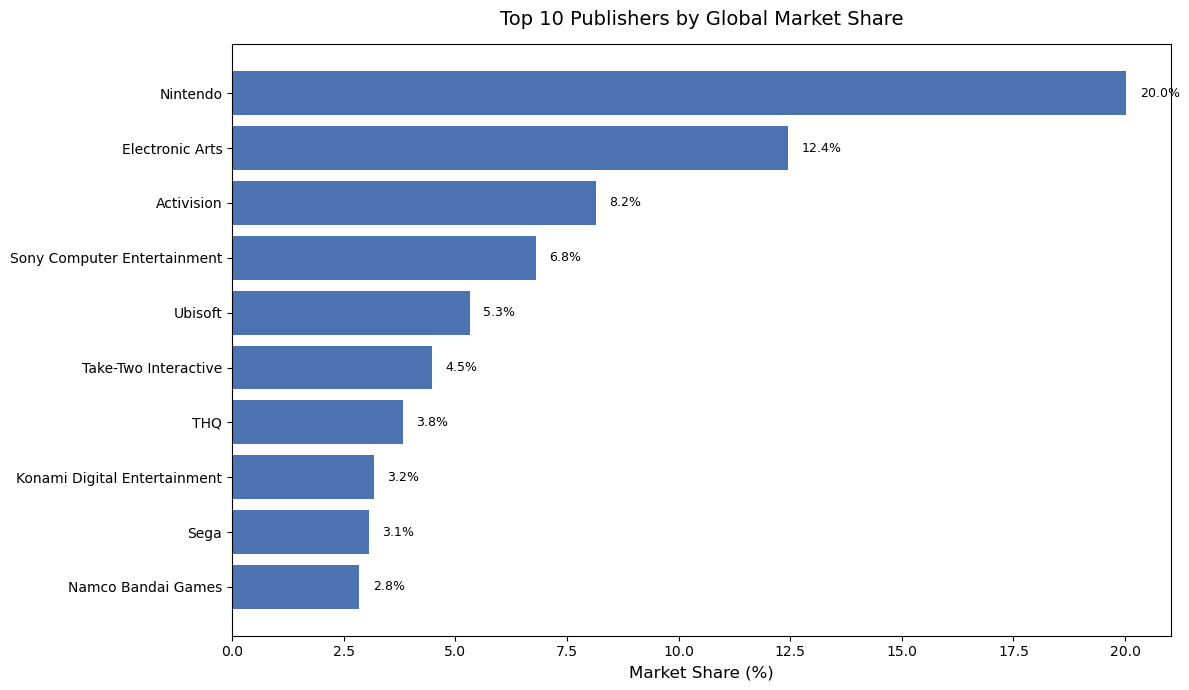

In [21]:
# Step 3 - Question 1 - Top Publishers by Global Sales Continued - Visual Exploration.

import matplotlib.pyplot as plt

# Top 10 Publishers by their Market Share.
top10_market_share = (
    publisher_share
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)   # smallest at bottom, largest at top
)

# Extract Labels and Values.
labels = top10_market_share.index
values = top10_market_share.values

# Horizontal Bar Chart.
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(labels, values, color="#4C72B0")

# Styling (Axes, Title, Labels)
ax.set_title("Top 10 Publishers by Global Market Share", fontsize=14, pad=14)
ax.set_xlabel("Market Share (%)", fontsize=12)
ax.set_ylabel("")

# Add value labels next to each bar
for i, (publisher, share) in enumerate(zip(top10_market_share.index, top10_market_share.values)):
    ax.text(share + 0.3, i, f"{share:.1f}%", 
            va="center", ha="left", fontsize=9)

# Final Steps - Tight Layout & Output.
plt.tight_layout()

plt.savefig("outputs/q1_publisher_concentration_v2.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# Step 2 - Question 1 - Top Publishers by Global Sales

# Q. Which publishers generate the highest total global sales, and how concentrated is the market among the top publishers?

# Total global sales by publisher
publisher_sales = (
        df.groupby("Publisher")["Global_Sales"].sum()
        .sort_values(ascending=False) 
)
publisher_sales.head(10)

# Total global sales across all games
total_global_sales = df["Global_Sales"].sum()

# Market share for each publisher
publisher_share = (publisher_sales / total_global_sales) * 100

publisher_share.head(10)

# Additional Data Exploration to verify Findings thus far.
print(f"Sum of publisher shares: {publisher_share.sum():.2f}%")
publisher_share.head(10).sum()

Sum of publisher shares: 99.83%


np.float64(70.14889400074433)

In [9]:
# Step 1 - Load & Inspect Dataset.

import pandas as pd
from pathlib import Path

SCRIPT_DIR = Path().resolve()
df = pd.read_csv(SCRIPT_DIR / "data" / "vgsales.csv")
df.columns = df.columns.str.strip()

# Standard inspection
df.shape
df.columns.tolist()
df.dtypes
df.head()
df["Publisher"].nunique()
df["Publisher"].value_counts().head(10)
df["Year"].min(), df["Year"].max()
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64